In [1]:
import sys
sys.path.append('..')

from models.compression.vq_vae import VQVAE
from dataset import ImageCompressionDataModule

In [2]:
device = "cpu"

model = VQVAE(
    h_dim=256,
    n_embeddings=1023,
    embedding_dim=64,
    beta=0.25,
    lr=1e-3,
    n_heads=4,
    n_layers=3,
    patch_size=1,
    freeze_encoder=True, 
    freeze_decoder=True, 
    freeze_quantizer=True,  
    load_params=["encoder", "decoder", "vector_quantization"],
    load_path="../../checkpoints/stage1/vq_vae_quantizer_pretrain-v18.ckpt",
    is_fsq=False,
)

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/home/vedpatel/.conda/envs/image_compression/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vedpatel/.conda/envs/image_compression/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/vedpatel/.conda/envs/image_compression/lib/python3.11/site-packages/lpips/weights/v0.1/vgg.pth
Encoder frozen
Decoder frozen
Quantizer frozen
Loading components ['encoder', 'decoder', 'vector_quantization'] from ../../checkpoints/stage1/vq_vae_quantizer_pretrain-v18.ckpt
Loaded 97 parameters for encoder
Loaded 65 parameters for decoder
Loaded 8 parameters for vector_quantization
VQVAE __init__ complete.


In [3]:
dataset = ImageCompressionDataModule(
    data_dir="../../data/PetImages",
    batch_size=1,
)

dataset=dataset.setup()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9902866..0.9946702].


Input images shape: torch.Size([1, 3, 448, 448])
Reconstructed images shape: torch.Size([1, 3, 448, 448])
Latent indices shape: torch.Size([2, 1, 2, 56, 56])


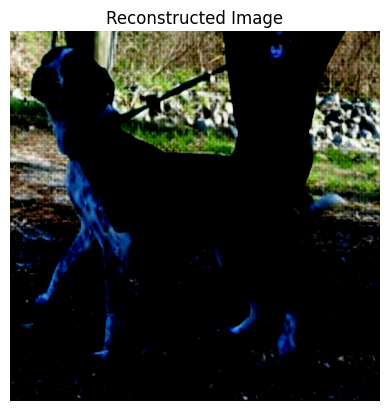

In [4]:
import matplotlib.pyplot as plt

for batch in dataset.train_dataloader():
    imgs, _ = batch
    imgs = imgs.to(device)
    _, recons, latents, _ = model(imgs)
    print("Input images shape:", imgs.shape)
    print("Reconstructed images shape:", recons.shape)
    print("Latent indices shape:", latents.shape,)
    
    plt.imshow(recons[0].permute(1, 2, 0).detach().cpu().numpy())
    plt.title("Reconstructed Image")
    plt.axis("off")
    plt.show()
    
    break

In [ ]:
import bitstruct
import numpy as np

flat_latents = latents.flatten().tolist()

# Calculate bits needed for your codebook size (1023 needs 10 bits)
bits_per_value = 10
num_values = len(flat_latents)

# Use a single format string without spaces (more efficient)
fmt = f'u{bits_per_value}' * num_values

packed = bitstruct.pack(fmt, *flat_latents)
unpacked = bitstruct.unpack(fmt, packed)

unpacked_array = np.array(unpacked).reshape(latents.shape)

latents_np = latents.cpu().numpy() if hasattr(latents, 'cpu') else latents

print(np.array_equal(unpacked_array, latents_np))

original_bits = latents.numel() * 32 
packed_bits = len(packed) * 8
print(f"Original: {original_bits} bits ({original_bits // 8} bytes)")
print(f"Packed: {packed_bits} bits ({len(packed)} bytes)")
print(f"Compression ratio: {original_bits / packed_bits:.2f}x")

True
Original: 401408 bits (50176 bytes)
Packed: 125440 bits (15680 bytes)
Compression ratio: 3.20x


In [19]:
import zlib

compressed = zlib.compress(packed, level=9)
print(f"After zlib: {len(compressed)} bytes")

decompressed = zlib.decompress(compressed)
unpacked_decompressed = bitstruct.unpack(fmt, decompressed)
unpacked_decompressed_array = np.array(unpacked_decompressed).reshape(latents.shape)

print(np.array_equal(unpacked_decompressed_array, latents_np))

After zlib: 15691 bytes
True


In [ ]:
import os
from collections import Counter

cat_dir = "../../data/PetImages/Cat"
dog_dir = "../../data/PetImages/Dog"

def average_file_size(directory):
    sizes = []
    for fname in os.listdir(directory):
        fpath = os.path.join(directory, fname)
        if os.path.isfile(fpath):
            sizes.append(os.path.getsize(fpath))
    return sum(sizes) / len(sizes) if sizes else 0

def most_popular_extension(directory):
    exts = []
    for fname in os.listdir(directory):
        _, ext = os.path.splitext(fname)
        if ext:
            exts.append(ext.lower())
    if exts:
        return Counter(exts).most_common(1)[0]
    return None

avg_cat = average_file_size(cat_dir)
avg_dog = average_file_size(dog_dir)
cat_ext = most_popular_extension(cat_dir)
dog_ext = most_popular_extension(dog_dir)

print(f"Average Cat file size: {avg_cat:.2f} bytes, Extensions: {cat_ext}")
print(f"Average Dog file size: {avg_dog:.2f} bytes, Extensions: {dog_ext}")

Average Cat file size: 31343.61 bytes, Most popular extension: ('.jpg', 12490)
Average Dog file size: 37924.72 bytes, Most popular extension: ('.jpg', 12469)
